# A/B Testing Analysis of Digital Campaigns: Evaluating Conversion Rates and Business Impact

## Introduction

## Data Cleaning and Preparation

In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv("data/marketing_AB.csv")

df["ad"] = df["test group"].apply(lambda x: 1 if x.strip() == "ad" else 0)
df.head()

,index,user id,test group,converted,total ads,most ads day,most ads hour,ad
0,0,1069124,ad,False,130,Monday,20,1
1,1,1119715,ad,False,93,Tuesday,22,1
2,2,1144181,ad,False,21,Tuesday,18,1
3,3,1435133,ad,False,355,Tuesday,10,1
4,4,1015700,ad,False,276,Friday,14,1


In [3]:
df.isna().sum()

index            0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
ad               0
dtype: int64

In [4]:
df.columns = df.columns.str.strip()  # Remove leading/trailing whitespace from column names

We want to see how the conversion rates differ between the two groups (A and B). We can calculate the conversion rate for each group and then perform a statistical test to see if the difference is statistically significant. Group A is the control (PSA) group, and Group B is the treatment group (ad). We will use a two-proportion z-test and a 95% confidence interval to compare the conversion rates of the two groups.

#### Group Balance Check

In [5]:
print(df["test group"].value_counts(normalize=True))  #Highly imblanced
print(f"Overall conversion rate: {df["converted"].value_counts(normalize=True)[True]:.2%}")

test group
ad     0.96
psa    0.04
Name: proportion, dtype: float64
Overall conversion rate: 2.52%


### What sample size do we need to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%?

In [6]:
from statsmodels.stats.power import NormalIndPower

p1 = df[df["ad"] == 1]["converted"].mean()  # Conversion rate for the ad group
p0 = df[df["ad"] == 0]["converted"].mean()  # Conversion rate for the PSA group
#PSA / ad ratio
r = (len(df[df["ad"] == 0])/len(df[df["ad"] == 1]))  # Ratio of the sizes of the two groups
n = len(df)  # Total sample size

#Standardized effect size
effect_size = (p1 - p0) / np.sqrt(p0 * (1 - p0)) #Divides by the standard deviation of the control group
power_analysis = NormalIndPower()

n1 = power_analysis.solve_power(
    effect_size = effect_size,
    alpha       = 0.05,   # 95% confidence level
    power       = 0.80,   # 80% power, 20% chance of Type II error (false negative, failing to detect a true effect)
    ratio       = r,      # unequal group ratio
    alternative = 'two-sided'
)

n2 = n1 * r
print(f"Required sample size for the ad group (treatment): {n1:.0f}")
print(f"Required sample size for the PSA group (control): {n2:.0f}")


Required sample size for the ad group (treatment): 58148
Required sample size for the PSA group (control): 2423


#### Do we have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%?

In [7]:
if n1 + n2 <= n:
    print("We have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%.")
else:
    print("We do NOT have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%.")

if n1 <= len(df[df["ad"] == 1]) and n2 <= len(df[df["ad"] == 0]):
    print("We have enough samples in each group to perform the test.")
else:
    print("We do NOT have enough samples in each group to perform the test.")

We have the required sample size to detect a significant difference in conversion rates between the two groups with a power of 80% and a significance level of 5%.
We have enough samples in each group to perform the test.


## Two-Proportion Z-Test

To test the hypothesis that the conversion rates between the two groups are different, we can use methods such as a two-proportion z-test or a confidence interval analysis. We will calculate the conversion rates for both groups and then perform the statistical test to determine if the observed difference is statistically significant.

In [8]:
from statsmodels.stats.proportion import proportions_ztest

conversions = df.groupby('ad')['converted'].sum()
counts = df.groupby('ad')['converted'].count()
print("Conversion rates: \n", conversions / counts)
group_counts = df.groupby('ad')['converted'].count()

stat, pval = proportions_ztest(conversions, group_counts)

print("Z-stat:", stat)
print("P-value:", pval)
significance_level = 0.05
if pval < significance_level:
    print("Reject the null hypothesis: There is a significant difference in conversion rates between groups A and B.")
else:
    print("Fail to reject the null hypothesis: No significant difference detected.")

Conversion rates: 
 ad
0    0.017854
1    0.025547
Name: converted, dtype: float64
Z-stat: -7.3700781265454145
P-value: 1.7052807161559727e-13
Reject the null hypothesis: There is a significant difference in conversion rates between groups A and B.


### Confidence Intervals for Conversion Rates

In [9]:
p_ad = df[df['ad']==1]['converted'].mean()
p_psa = df[df['ad']==0]['converted'].mean()

n_ad = len(df[df['ad']== 1])
n_psa = len(df[df['ad']==0])

diff = p_ad - p_psa

se = np.sqrt((p_ad*(1-p_ad)/n_ad) + (p_psa*(1-p_psa)/n_psa))
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print(f"Difference = {diff} \n95% Confidence interval: ({ci_lower}, {ci_upper})")

Difference = 0.007692453192201517 
95% Confidence interval: (0.00595090043017032, 0.009434005954232714)


Since 0 is not included in the 95% confidence interval, we can conclude that there is a statistically significant difference in conversion rates between the two groups. This suggests that the ad group has an estimated 0.77% higher conversion rate compared to the PSA group, and the observed difference is unlikely to be due to random chance.

## Visualizations

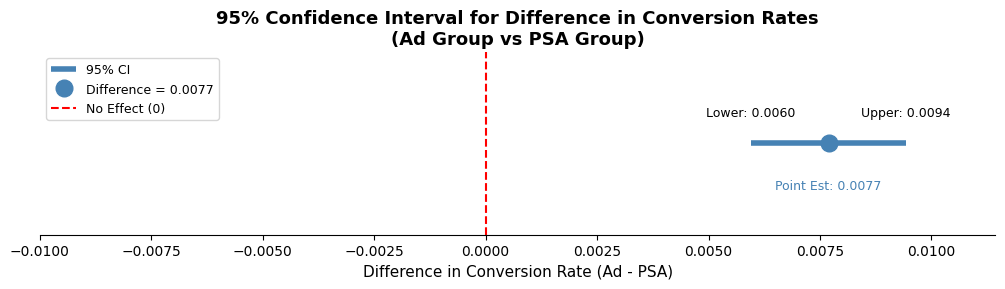

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 3))

# Plot the CI as a horizontal line
ax.hlines(y=0, xmin=ci_lower, xmax=ci_upper, linewidth=4, color='steelblue', label='95% CI')

# Plot the point estimate (diff)
ax.plot(diff, 0, 'o', color='steelblue', markersize=12, zorder=5, label=f'Difference = {diff:.4f}')

# Add vertical line at zero to show significance boundary
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='No Effect (0)')

# Annotate the bounds
ax.text(ci_lower, 0.15, f'Lower: {ci_lower:.4f}', ha='center', fontsize=9, color='black')
ax.text(ci_upper, 0.15, f'Upper: {ci_upper:.4f}', ha='center', fontsize=9, color='black')
ax.text(diff, -0.25, f'Point Est: {diff:.4f}', ha='center', fontsize=9, color='steelblue')

# Formatting
ax.set_xlim(ci_lower - 0.002, ci_upper + 0.002)
ax.set_ylim(-0.5, 0.5)
ax.set_yticks([])
ax.set_xlabel('Difference in Conversion Rate (Ad - PSA)', fontsize=11)
ax.set_title('95% Confidence Interval for Difference in Conversion Rates\n(Ad Group vs PSA Group)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('ci_plot.png', dpi=150, bbox_inches='tight')
plt.xlim(-0.01, ci_upper + 0.002)
plt.show()